In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
pip install tensorflow-text

In [ ]:
pip install sentencepiece

In [ ]:
!pip install pytorch-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from keras.utils import pad_sequences
from sklearn.model_selection import train_test_split


from transformers import XLNetModel, XLNetTokenizer, XLNetForSequenceClassification
from torch.optim import AdamW

from tqdm import tqdm, trange
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import tensorflow as tf
import tensorflow_text as tf_text
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns  # Import seaborn for visualization


device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))


Found GPU at: /device:GPU:0


In [ ]:
!pip install transformers datasets torch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpu = torch.cuda.device_count()
torch.cuda.get_device_name(0)

'Tesla T4'

In [ ]:
df = pd.read_csv("/content/Dataset Cyberbullying Media Sosial.csv")

In [ ]:
df

,Text,Label,CaseFold,RegRemoval,SymbolsRemoval
0,Oooo statusnya masih darurat tho?... Daruratny...,0,oooo statusnya masih darurat tho?... daruratny...,oooo statusnya masih darurat tho?... daruratny...,oooo statusnya masih darurat tho?... daruratny...
1,Pembicaraan antar profesor pas mengemukakan pe...,1,pembicaraan antar profesor pas mengemukakan pe...,pembicaraan antar profesor pas mengemukakan pe...,pembicaraan antar profesor pas mengemukakan pe...
2,nonton cuma liat timecode berjalan...soalnya k...,1,nonton cuma liat timecode berjalan...soalnya k...,nonton cuma liat timecode berjalan...soalnya k...,nonton cuma liat timecode berjalan...soalnya k...
3,Kura kura Galapagos dan ikan laut dalam palung...,1,kura kura galapagos dan ikan laut dalam palung...,kura kura galapagos dan ikan laut dalam palung...,kura kura galapagos dan ikan laut dalam palung...
4,Podcast 3 makhluk ghoib.,1,podcast 3 makhluk ghoib.,podcast makhluk ghoib.,podcast makhluk ghoib.
...,...,...,...,...,...
66630,Istinysaq (Memasukkan air dalam hidung) serta ...,0,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...
66631,Istinysaq (Memasukkan air dalam hidung) serta ...,0,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...
66632,Repost @kompascom (Berita selengkapnya klik IG...,0,repost @kompascom (berita selengkapnya klik ig...,repost @kompascom (berita selengkapnya klik ig...,repost @kompascom (berita selengkapnya klik ig...
66633,jasaakuntansi.pajak Menyediakan jasa pengerjaa...,0,jasaakuntansi.pajak menyediakan jasa pengerjaa...,jasaakuntansi.pajak menyediakan jasa pengerjaa...,jasaakuntansi.pajak menyediakan jasa pengerjaa...


In [ ]:
df.drop(["CaseFold", "RegRemoval", "SymbolsRemoval"],axis=1,inplace=True)

In [ ]:
df

,Text,Label
0,Oooo statusnya masih darurat tho?... Daruratny...,0
1,Pembicaraan antar profesor pas mengemukakan pe...,1
2,nonton cuma liat timecode berjalan...soalnya k...,1
3,Kura kura Galapagos dan ikan laut dalam palung...,1
4,Podcast 3 makhluk ghoib.,1
...,...,...
66630,Istinysaq (Memasukkan air dalam hidung) serta ...,0
66631,Istinysaq (Memasukkan air dalam hidung) serta ...,0
66632,Repost @kompascom (Berita selengkapnya klik IG...,0
66633,jasaakuntansi.pajak Menyediakan jasa pengerjaa...,0


In [ ]:
df.isna().sum()

,0
Text,0
Label,0


In [ ]:
df['Text'] = df['Text'].str.replace('[^a-zA-Z0-9\s]+', '', regex=True)
df

,Text,Label
0,Oooo statusnya masih darurat tho Daruratnya di...,0
1,Pembicaraan antar profesor pas mengemukakan pe...,1
2,nonton cuma liat timecode berjalansoalnya kaga...,1
3,Kura kura Galapagos dan ikan laut dalam palung...,1
4,Podcast 3 makhluk ghoib,1
...,...,...
66630,Istinysaq Memasukkan air dalam hidung serta Is...,0
66631,Istinysaq Memasukkan air dalam hidung serta Is...,0
66632,Repost kompascom Berita selengkapnya klik IG S...,0
66633,jasaakuntansipajak Menyediakan jasa pengerjaan...,0


In [ ]:
labels = df['Label']
unique_labels = labels.unique()
unique_labels

array([0, 1])

In [ ]:
df['Label'].value_counts()

,count
Label,
0,60487
1,6148


In [ ]:
# Menggabungkan teks dan label untuk mempermudah pengolahan
data = pd.DataFrame({'Text': df['Text'], 'Label': labels})

# Memisahkan data berdasarkan label
label_0 = data[data['Label'] == 0]
label_1 = data[data['Label'] == 1]

# Undersampling ke ukuran yang sama
from sklearn.utils import resample # Import resample if it's not already imported

# Menentukan ukuran terkecil
min_size = min(len(label_0), len(label_1))

# Melakukan undersampling pada label mayoritas
label_0_undersampled = resample(label_0,
                                 replace=False, # Without replacement (no duplicates)
                                 n_samples=min_size, # Match the minority class size
                                 random_state=42) # For reproducibility

# Gabungkan kembali data yang telah di-undersample
undersampled_data = pd.concat([label_0_undersampled, label_1])

# Perbarui df dengan data yang telah di-undersample
df = undersampled_data.copy()

In [ ]:
df['Label'].value_counts()

,count
Label,
0,6148
1,6148


In [ ]:
df

,Text,Label
26489,Bucin,0
15811,Salute buat Deny cagur kuat banget,0
6602,Cheewyxizy iyaa kaka sayang semua boleh komen ...,0
32938,Fajar lu di kasih tisu itu buat lap air mata l...,0
36625,Kayanya dia butuh psikolog,0
...,...,...
66538,Ada yang kena omel TKW Indonesia nih Mbak TKW ...,1
66590,Coba makanya deh itu pegawai bea cukai produc...,1
66592,Indonesia urutan ke berapa ya Hi Monefriends...,1
66594,Rubicon nya siapa nih Lebih kaget lagi kalo li...,1


In [ ]:
import re
import string
def clean_text(text):
#    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
#    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

In [ ]:
df['text_clean'] = df['Text'].apply(clean_text)
df.sample(10)

,Text,Label,text_clean
53061,Ni konten ter ngakakk siiiibrMaaf ya Fajar,0,ni konten ter ngakakk siiiibrmaaf ya fajar
4850,Aries Afvig ANIES emang MasyaAllah Capres yg p...,1,aries afvig anies emang masyaallah capres yg p...
18159,Ripuuh ahhh Aya Wee NU kt,0,ripuuh ahhh aya wee nu kt
53898,Ini cerita sedih sbnrnya tp maaf aku malah ket...,0,ini cerita sedih sbnrnya tp maaf aku malah ket...
1502,Meta baru di mli sepertinya,1,meta baru di mli sepertinya
1690,Oh yg jadi putra mahkota anak dari raja injo i...,1,oh yg jadi putra mahkota anak dari raja injo i...
731,3 penduduk somalia,1,penduduk somalia
4457,wahai rakyat Indonesia Nusantara sadarlahbrA...,1,wahai rakyat indonesia nusantara sadarlahbra...
4991,Lha bApa yang diharapkan dari begundall wbd yg...,1,lha bapa yang diharapkan dari begundall wbd yg...
36367,Mau ketawa takut dosa,0,mau ketawa takut dosa


In [ ]:
df['Text'] = df['text_clean'].copy()
df.sample(10)

,Text,Label,text_clean
65517,waspadalah sikadrun itu teroris wahabihtifpi d...,1,waspadalah sikadrun itu teroris wahabihtifpi d...
65172,kalo beneran nikah sama shohei gajadi childfre...,1,kalo beneran nikah sama shohei gajadi childfre...
62880,minta ganti wkawwww dong,0,minta ganti wkawwww dong
269,susah untuk dimengerti,1,susah untuk dimengerti
4371,anieis baru resmi dicalonkan partai blm resmi...,1,anieis baru resmi dicalonkan partai blm resmi...
64918,bikin kram otak saya,0,bikin kram otak saya
4710,maling star,1,maling star
2782,jangan makan uang haram,1,jangan makan uang haram
65216,ada ga ya cowo yang pengen childfree please dm...,1,ada ga ya cowo yang pengen childfree please dm...
668,kombinasi kematian untuk telinga anda semua,1,kombinasi kematian untuk telinga anda semua


In [ ]:
# STOPWORDS
import nltk
#nltk.download('stopwords')
#stop_words = stopwords.words('english')
#more_stopwords = ['u', 'im', 'c']
#stop_words = stop_words + more_stopwords

#def remove_stopwords(text):
#    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
#    return text

#df['text_clean'] = df['text_clean'].apply(remove_stopwords)
#df.head()

In [ ]:
df

,Text,Label,text_clean
26489,bucin,0,bucin
15811,salute buat deny cagur kuat banget,0,salute buat deny cagur kuat banget
6602,cheewyxizy iyaa kaka sayang semua boleh komen ...,0,cheewyxizy iyaa kaka sayang semua boleh komen ...
32938,fajar lu di kasih tisu itu buat lap air mata l...,0,fajar lu di kasih tisu itu buat lap air mata l...
36625,kayanya dia butuh psikolog,0,kayanya dia butuh psikolog
...,...,...,...
66538,ada yang kena omel tkw indonesia nih mbak tkw ...,1,ada yang kena omel tkw indonesia nih mbak tkw ...
66590,coba makanya deh itu pegawai bea cukai produc...,1,coba makanya deh itu pegawai bea cukai produc...
66592,indonesia urutan ke berapa ya hi monefriends...,1,indonesia urutan ke berapa ya hi monefriends...
66594,rubicon nya siapa nih lebih kaget lagi kalo li...,1,rubicon nya siapa nih lebih kaget lagi kalo li...


In [ ]:
text = df['Text'].tolist() # Create text list from df['Text']
text = [Text + " [SEP] [CLS]" for Text in text]
label = df.Label.values

In [ ]:
#tweet = pd.DataFrame(tweet)

In [ ]:
#tweet.to_csv('tweet.csv')

In [ ]:
tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased', do_lower_case=True)

tokenized_text = [tokenizer.tokenize(sent) for sent in text]
print ("Tokenize the first sentence:")
print (tokenized_text[0])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

Tokenize the first sentence:
['▁', 'bu', 'cin', '▁[', 's', 'ep', ']', '▁[', 'cl', 's', ']']


In [ ]:
#tokenized_tweet = pd.DataFrame(tokenized_tweet)
#tokenized_tweet.to_csv('token.csv')

In [ ]:
# Set the maximum sequence length. The longest sequence in our training set is 47, but we'll leave room on the end anyway.
MAX_LEN = 128

In [ ]:
# Use the XLNet tokenizer to convert the tokens to their index numbers in the XLNet vocabulary
input_ids = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_text]

In [ ]:
# Pad our input tokens
input_ids = pad_sequences(input_ids, maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")

In [ ]:
# Create attention masks
attention_masks = []

# Create a mask of 1s for each token followed by 0s for padding
for seq in input_ids:
  seq_mask = [float(i>0) for i in seq]
  attention_masks.append(seq_mask)

# Use train_test_split to split our data into train and testing sets for training
labels = df.Label.values # Update labels with the undersampled labels
train_inputs, test_inputs, train_labels, test_labels = train_test_split(input_ids, labels,
                                                            random_state=2018, test_size=0.2)
train_masks, test_masks, _, _ = train_test_split(attention_masks, input_ids,
                                             random_state=2018, test_size=0.2)

In [ ]:
# Convert all of our data into torch tensors, the required datatype for our model

train_inputs = torch.tensor(train_inputs)
test_inputs = torch.tensor(test_inputs)
train_labels = torch.tensor(train_labels)
test_labels = torch.tensor(test_labels)
train_masks = torch.tensor(train_masks)
test_masks = torch.tensor(test_masks)

In [ ]:
# Select a batch size for training. For fine-tuning with XLNet, the authors recommend a batch size of 32, 48, or 128. We will use 32 here to avoid memory issues.
batch_size = 64

# Create an iterator of our data with torch DataLoader. This helps save on memory during training because, unlike a for loop,
# with an iterator the entire dataset does not need to be loaded into memory

train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

test_data = TensorDataset(test_inputs, test_masks, test_labels)
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)

In [ ]:
#input_ids_tweet

In [ ]:
class CNNModel(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):  # Add dropout_rate as a parameter
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=768, out_channels=256, kernel_size=3)
        self.conv2 = nn.Conv1d(in_channels=256, out_channels=128, kernel_size=3)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.fc1_input_size = self._get_fc1_input_size(MAX_LEN, 768)
        self.fc1 = nn.Linear(self.fc1_input_size, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(dropout_rate)  # Create a dropout layer


    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout after the first fully connected layer
        x = self.fc2(x)
        return x

    def _get_fc1_input_size(self, max_len, hidden_size):
        dummy_input = torch.randn(1, hidden_size, max_len)
        dummy_output = self.pool(F.relu(self.conv1(dummy_input)))
        dummy_output = self.pool(F.relu(self.conv2(dummy_output)))
        return dummy_output.view(1, -1).size(1)

In [ ]:
# Load XLNetForSequenceClassification, the pretrained XLNet model with a single linear classification layer on top.
xlnet_model = XLNetForSequenceClassification.from_pretrained("xlnet-base-cased", num_labels=2)
xlnet_model.cuda()

# Inisialisasi model CNN
cnn_model = CNNModel(num_classes=2)

# Specifying a custom dropout rate (e.g., 0.2)
cnn_model = CNNModel(num_classes=2, dropout_rate=0.2)


cnn_model.cuda()

class CombinedModel(nn.Module):
    def __init__(self, xlnet_model, cnn_model):
        super(CombinedModel, self).__init__()
        self.xlnet = xlnet_model
        self.cnn = cnn_model

    def forward(self, input_ids, attention_mask):
        # Get the hidden states from XLNet instead of the logits
        xlnet_output = self.xlnet(input_ids, attention_mask=attention_mask, output_hidden_states=True)
        hidden_states = xlnet_output.hidden_states[-1]  # Get the last hidden state

        # Reshape to match CNN input expectations (batch_size, channels, sequence_length)
        # hidden_states has shape (batch_size, sequence_length, hidden_size)
        cnn_input = hidden_states.permute(0, 2, 1)  # Reshape to (batch_size, hidden_size, sequence_length)

        return self.cnn(cnn_input)

# Inisialisasi model gabungan
model = CombinedModel(xlnet_model, cnn_model)
model.cuda()

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


CombinedModel(
  (xlnet): XLNetForSequenceClassification(
    (transformer): XLNetModel(
      (word_embedding): Embedding(32000, 768)
      (layer): ModuleList(
        (0-11): 12 x XLNetLayer(
          (rel_attn): XLNetRelativeAttention(
            (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (ff): XLNetFeedForward(
            (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (layer_1): Linear(in_features=768, out_features=3072, bias=True)
            (layer_2): Linear(in_features=3072, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
            (activation_function): GELUActivation()
          )
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (sequence_summary): SequenceSummary(
      (summary): Linear(in_features=768, out_features=768, bias=Tr

In [ ]:
param_optimizer = list(model.named_parameters())
no_decay = ['bias', 'gamma', 'beta']
optimizer_grouped_parameters = [
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.01},
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.0}
]

In [ ]:
# This variable contains all of the hyperparemeter information our training loop needs
optimizer = AdamW(optimizer_grouped_parameters,
                     lr=2e-5)

In [ ]:
# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Train loss: 0.6725757617455024
Testing Accuracy: 0.6607142857142857
Accuracy: 0.6609756097560976
Precision: 0.6594090202177294
Recall: 0.6816720257234726
F1-Score: 0.6703557312252965


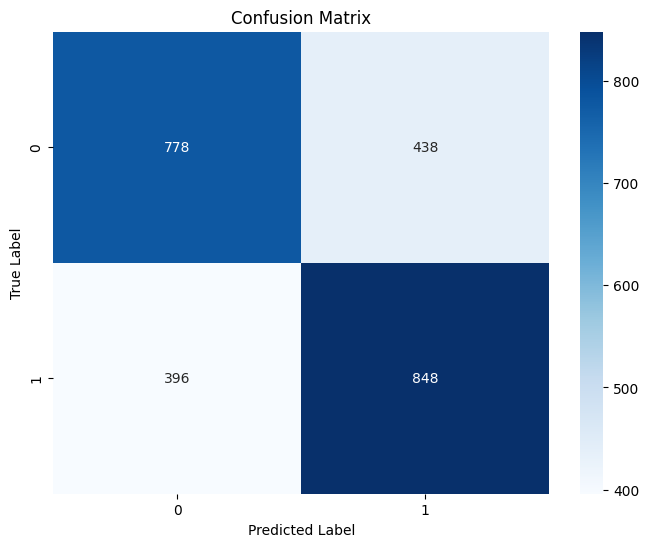

Epoch:  10%|█         | 1/10 [05:08<46:15, 308.38s/it]

Saved the best model with testing accuracy: 0.6607142857142857
Train loss: 0.5626698424676796
Testing Accuracy: 0.7338598901098902
Accuracy: 0.7341463414634146
Precision: 0.7178729689807977
Recall: 0.7813504823151125
F1-Score: 0.7482678983833718


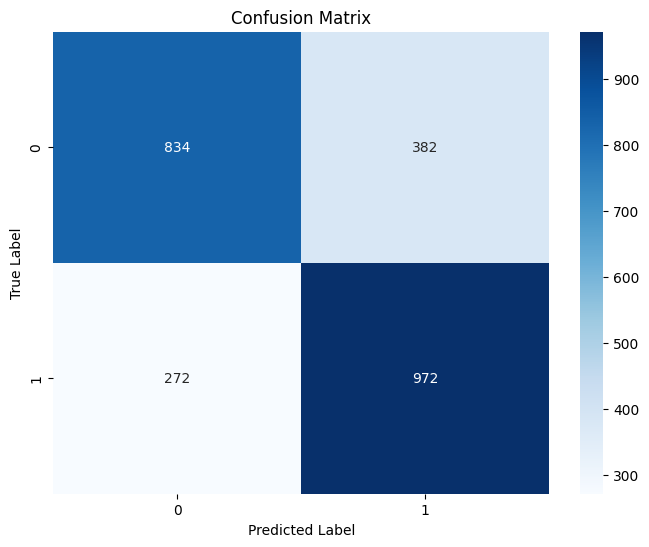

Epoch:  20%|██        | 2/10 [10:22<41:33, 311.74s/it]

Saved the best model with testing accuracy: 0.7338598901098902
Train loss: 0.49851462844904365
Testing Accuracy: 0.7485119047619048
Accuracy: 0.7479674796747967
Precision: 0.7630691399662732
Recall: 0.727491961414791
F1-Score: 0.7448559670781892


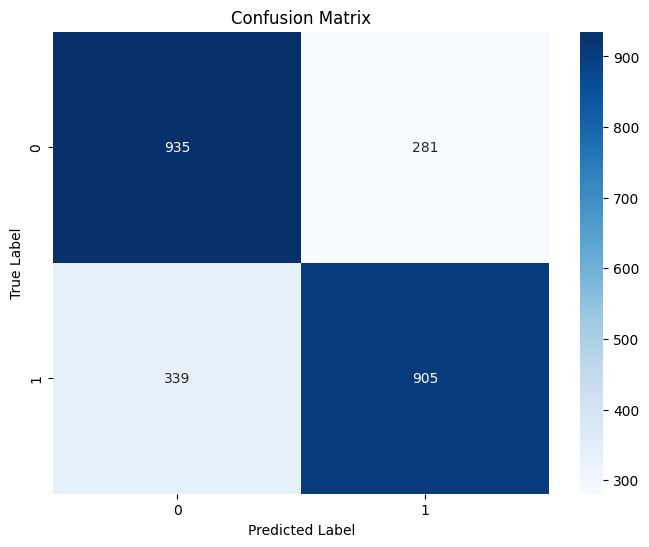

Epoch:  30%|███       | 3/10 [15:36<36:28, 312.59s/it]

Saved the best model with testing accuracy: 0.7485119047619048
Train loss: 0.43733602084896783
Testing Accuracy: 0.7626488095238095
Accuracy: 0.7617886178861789
Precision: 0.7530769230769231
Recall: 0.7869774919614148
F1-Score: 0.7696540880503143


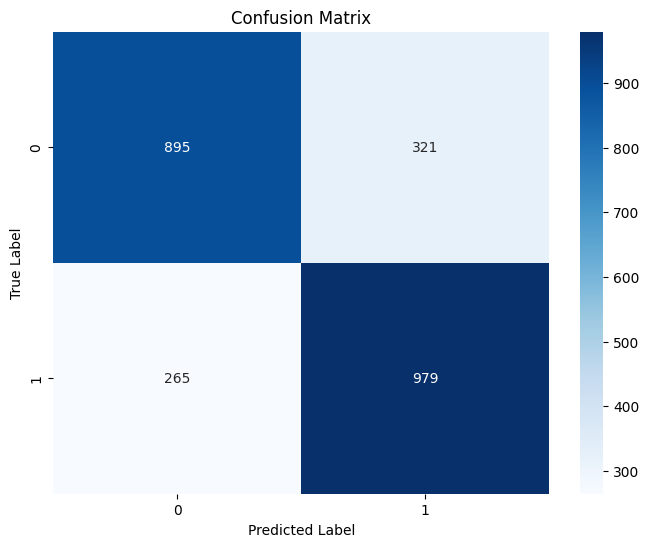

Epoch:  40%|████      | 4/10 [20:49<31:18, 313.09s/it]

Saved the best model with testing accuracy: 0.7626488095238095
Train loss: 0.384521244988813
Testing Accuracy: 0.7718635531135531
Accuracy: 0.7711382113821138
Precision: 0.766223612197029
Recall: 0.7877813504823151
F1-Score: 0.7768529528339279


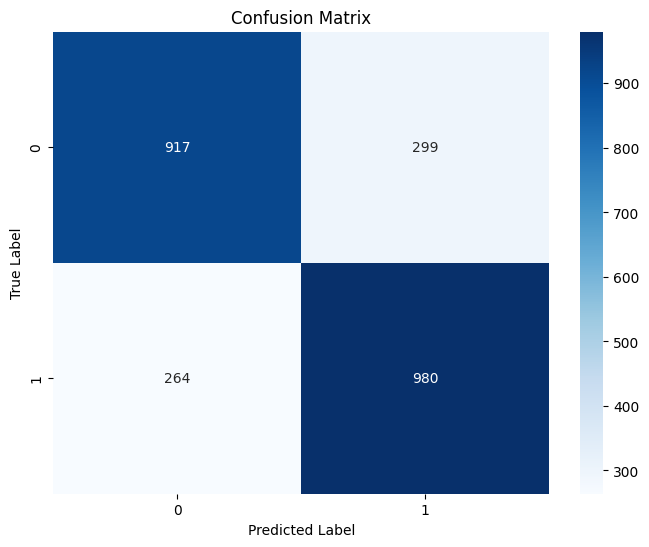

Epoch:  50%|█████     | 5/10 [26:04<26:07, 313.59s/it]

Saved the best model with testing accuracy: 0.7718635531135531
Train loss: 0.33832748292328474
Testing Accuracy: 0.7646520146520147
Accuracy: 0.7638211382113821
Precision: 0.7524752475247525
Recall: 0.7942122186495176
F1-Score: 0.7727806022682832


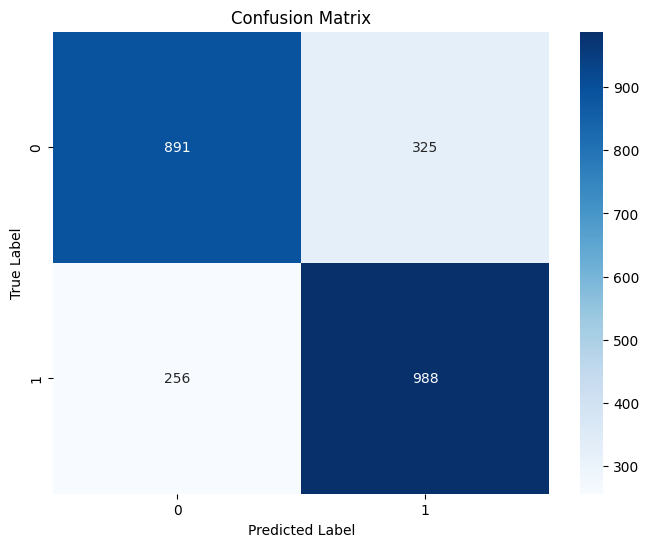

Epoch:  60%|██████    | 6/10 [31:11<20:45, 311.38s/it]

Train loss: 0.29770701330203514
Testing Accuracy: 0.7609317765567766
Accuracy: 0.760569105691057
Precision: 0.7759056444818871
Recall: 0.7403536977491961
F1-Score: 0.7577128753599341


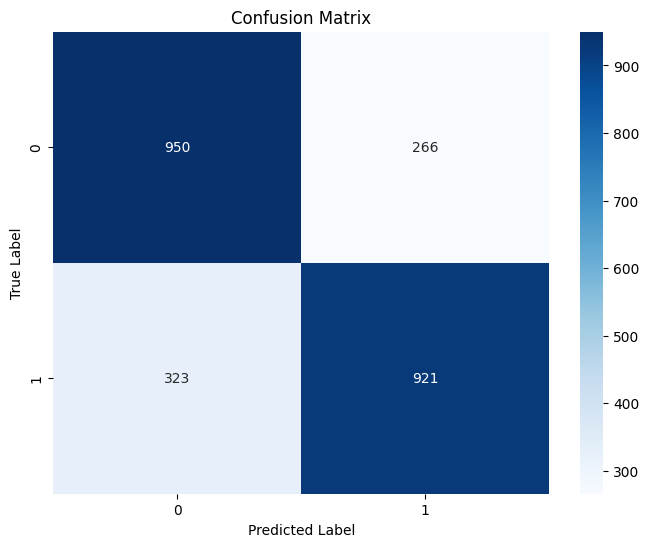

Epoch:  70%|███████   | 7/10 [36:18<15:29, 309.89s/it]

Train loss: 0.24854616583748299
Testing Accuracy: 0.7603021978021979
Accuracy: 0.7609756097560976
Precision: 0.7433234421364985
Recall: 0.8054662379421221
F1-Score: 0.773148148148148


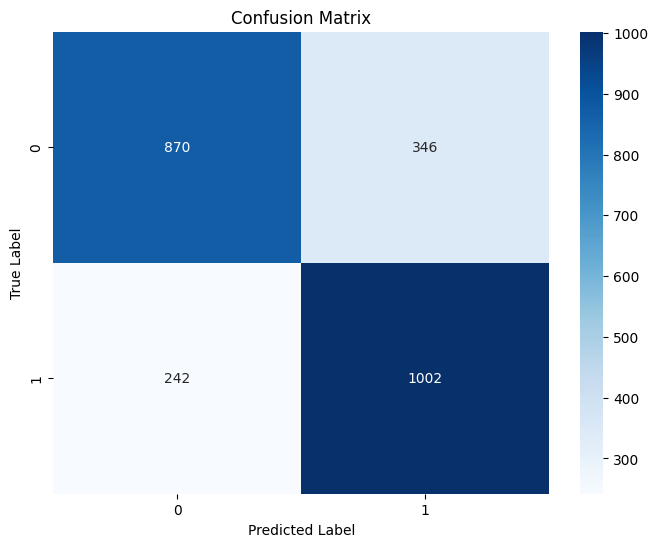

Epoch:  70%|███████   | 7/10 [41:25<17:45, 355.05s/it]

Early stopping! No improvement for 3 consecutive epochs.


In [ ]:
# Store our loss and accuracy for plotting
train_loss_set = []

# Number of training epochs (authors recommend between 2 and 4)
epochs = 10

# Directory to save the best model
save_dir = "/content/drive/MyDrive/XLNet-CNNFix/Model"

best_epoch = 0

os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "text_model.pth")

# Initialize early stopping parameters
best_eval_accuracy = 0.0
patience = 3  # Number of epochs with no improvement after which training will be stopped
early_stopping_counter = 0

# List untuk menyimpan metrik evaluasi setiap epoch
epoch_accuracy = []
epoch_precision = []
epoch_recall = []
epoch_f1 = []
all_confusion_matrices = []

# Initialize best_cm outside the loop
best_cm = None

# trange is a tqdm wrapper around the normal python range
for _ in trange(epochs, desc="Epoch"):

  # Training

  # Set our model to training mode (as opposed to evaluation mode)
  model.train()

  # Tracking variables
  tr_loss = 0
  nb_tr_examples, nb_tr_steps = 0, 0

  # Train the data for one epoch
  for step, batch in enumerate(train_dataloader):
    # Add batch to GPU
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch
    optimizer.zero_grad()
    outputs = model(b_input_ids, b_input_mask)
    loss = F.cross_entropy(outputs, b_labels)
    # Backward pass
    loss.backward()
    # Update parameters and take a step using the computed gradient
    optimizer.step()


    # Update tracking variables
    tr_loss += loss.item()
    nb_tr_examples += b_input_ids.size(0)
    nb_tr_steps += 1

  print("Train loss: {}".format(tr_loss/nb_tr_steps))


  # testing

  # Put model in evaluation mode to evaluate loss on the testing set
  model.eval()

  # Tracking variables
  eval_loss, eval_accuracy = 0, 0
  nb_eval_steps, nb_eval_examples = 0, 0

  # Store all labels and predictions for this epoch
  all_labels = []
  all_predictions = []
  all_confusion_matrices
  epoch_predictions = []


  # Evaluate data for one epoch
  for batch in test_dataloader:
    # Add batch to GPU
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch

    # Telling the model not to compute or store gradients, saving memory and speeding up testing
    with torch.no_grad():
        # Forward pass through the combined model
        outputs = model(b_input_ids, b_input_mask)

    # Move logits and labels to CPU
    logits = outputs.detach().cpu().numpy()  # Ambil output dari model gabungan
    label_ids = b_labels.to('cpu').numpy()

    # Store predictions and true labels
    predictions = np.argmax(logits, axis=1).flatten()  # Get predicted labels
    epoch_predictions.extend(predictions)  # Append to epoch_predictions
    all_labels.extend(label_ids)  # True labels

    tmp_eval_accuracy = flat_accuracy(logits, label_ids)

    eval_accuracy += tmp_eval_accuracy
    nb_eval_steps += 1

  print("Testing Accuracy: {}".format(eval_accuracy/nb_eval_steps))

  current_eval_accuracy = eval_accuracy / nb_eval_steps

  # Calculate and store evaluation metrics for the entire epoch (outside the batch loop)
  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
  accuracy = accuracy_score(all_labels, epoch_predictions)
  precision = precision_score(all_labels, epoch_predictions)
  recall = recall_score(all_labels, epoch_predictions)
  f1 = 2 * (precision * recall) / (precision + recall)


  epoch_accuracy.append(accuracy)
  epoch_precision.append(precision)
  epoch_recall.append(recall)
  epoch_f1.append(f1)

  print("Accuracy: {}".format(accuracy))  # Tampilkan akurasi epoch ini
  print("Precision: {}".format(precision))  # Tampilkan presisi epoch ini
  print("Recall: {}".format(recall))  # Tampilkan recall epoch ini
  print("F1-Score: {}".format(f1))  # Tampilkan F1-score epoch ini

  # Calculate confusion matrix
  cm = confusion_matrix(all_labels, epoch_predictions)

    # Simpan confusion matrix
  all_confusion_matrices.append(cm)

  # Display confusion matrix using seaborn heatmap
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=[0, 1], yticklabels=[0, 1])  # Customize labels if needed
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix")
  plt.show()

  # Check for early stopping
  if current_eval_accuracy > best_eval_accuracy:
      best_eval_accuracy = current_eval_accuracy
      early_stopping_counter = 0
      best_epoch = _ + 1
      best_cm = cm

      # Save the best model
      torch.save(model.state_dict(), best_model_path)
      print(f"Saved the best model with testing accuracy: {best_eval_accuracy}")
  else:
      early_stopping_counter += 1

  if early_stopping_counter >= patience:
      print(f"Early stopping! No improvement for {patience} consecutive epochs.")
      break  # Stop training


Hasil Evaluasi (Epoch Terbaik):
     Metrik     Nilai  Epoch Terbaik
0   Akurasi  0.771138              5
1   Presisi  0.766224              5
2    Recall  0.787781              5
3  F1-Score  0.776853              5


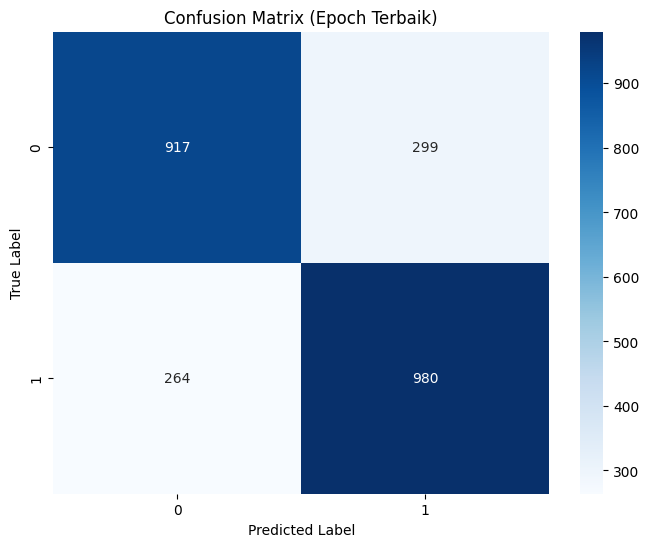

In [ ]:
data = {'Metrik': ['Akurasi', 'Presisi', 'Recall', 'F1-Score'],
        'Nilai': [epoch_accuracy[best_epoch - 1], epoch_precision[best_epoch - 1], epoch_recall[best_epoch - 1], epoch_f1[best_epoch - 1]],
        'Epoch Terbaik': [best_epoch, best_epoch, best_epoch, best_epoch]}
df_evaluasi = pd.DataFrame(data)
print("\nHasil Evaluasi (Epoch Terbaik):")
print(df_evaluasi)


# Access the confusion matrix using the valid index
best_cm

plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Epoch Terbaik)")
plt.show()